In [1]:
import xarray as xr
import numpy as np
import glob as glob
import functions
import matplotlib.pyplot as plt
import seaborn as sns
import cmcrameri

In [2]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/land_vars/'
ds_piClim = xr.open_dataset(rpath+'all_land_vars_piClim.nc')
ds_2xCO2 = xr.open_dataset(rpath+'all_land_vars_2xCO2.nc')
ds_4xCO2 = xr.open_dataset(rpath+'all_land_vars_4xCO2.nc')

In [3]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'
ds_piClim_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_20250529.soilsat.clm2.concatfiles.nc')
ds_2xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_2xCO2_20250529.soilsat.clm2.concatfiles.nc')
ds_4xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_4xCO2_20250529.soilsat.clm2.concatfiles.nc')

ds_piClim_xtra = functions.fix_clm_time(ds_piClim_xtra)
ds_2xCO2_xtra = functions.fix_clm_time(ds_2xCO2_xtra)
ds_4xCO2_xtra = functions.fix_clm_time(ds_4xCO2_xtra)

# Create new variables
ds_list = [ds_piClim, ds_2xCO2, ds_4xCO2]
ds_xtra_list = [ds_piClim_xtra, ds_2xCO2_xtra, ds_4xCO2_xtra]
for ds, ds_xtra in zip(ds_list, ds_xtra_list):
    tmp = ds_xtra['H2OSOI']
    #tmp_i = tmp.sel(levsoi=0) + tmp.sel(levsoi=1) + 2/3*tmp.sel(levsoi=2)
    #ds['H2OSOI_10CM'] = tmp_i

    tmp_i = tmp.sel(levsoi=0) + tmp.sel(levsoi=1) + tmp.sel(levsoi=2) + tmp.sel(levsoi=3)
    ds['H2OSOI_20CM'] = tmp_i

    tmp2 = ds_xtra['WATSAT']
    #tmp2_i = tmp2.isel(levgrnd=0) + tmp2.isel(levgrnd=1) + 2/3*tmp2.isel(levgrnd=2)
    #ds['WATSAT_10CM'] = tmp2_i

    tmp2_i = tmp2.isel(levgrnd=0) + tmp2.isel(levgrnd=1) + tmp2.isel(levgrnd=2) + tmp2.isel(levgrnd=3)
    ds['WATSAT_20CM'] = tmp2_i

    #ds['FSOILSAT_10CM'] = ds['H2OSOI_10CM']/ds['WATSAT_10CM']
    ds['FSOILSAT_20CM'] = ds['H2OSOI_20CM']/ds['WATSAT_20CM']
    

In [4]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'
ds_piClim_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_20250529.snow.clm2.concatfiles.nc')
ds_2xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_2xCO2_20250529.snow.clm2.concatfiles.nc')
ds_4xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_4xCO2_20250529.snow.clm2.concatfiles.nc')

In [5]:
# Fix time stamp
ds_piClim_xtra = functions.fix_clm_time(ds_piClim_xtra)
ds_2xCO2_xtra = functions.fix_clm_time(ds_2xCO2_xtra)
ds_4xCO2_xtra = functions.fix_clm_time(ds_4xCO2_xtra)

In [6]:
# Create new variables
ds_list = [ds_piClim, ds_2xCO2, ds_4xCO2]
ds_xtra_list = [ds_piClim_xtra, ds_2xCO2_xtra, ds_4xCO2_xtra]
for ds, ds_xtra in zip(ds_list, ds_xtra_list):
    ds['SNOW_FROM_ATM'] = ds_xtra['SNOW_FROM_ATM']

In [7]:
# Create new variables
ds_list = [ds_piClim, ds_2xCO2, ds_4xCO2]
for ds in ds_list:
    ds['PRECIP_TOTAL'] = ds['SNOW_FROM_ATM']+ds['RAIN_FROM_ATM']

In [8]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'
ds_piClim_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_20250529.permafrost.concatfiles.nc')
ds_2xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_2xCO2_20250529.permafrost.concatfiles.nc')
ds_4xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_4xCO2_20250529.permafrost.concatfiles.nc')

In [9]:
# Fix time stamp
ds_piClim_xtra = functions.fix_clm_time(ds_piClim_xtra)
ds_2xCO2_xtra = functions.fix_clm_time(ds_2xCO2_xtra)
ds_4xCO2_xtra = functions.fix_clm_time(ds_4xCO2_xtra)

In [10]:
# Create new variables
ds_list = [ds_piClim, ds_2xCO2, ds_4xCO2]
ds_xtra_list = [ds_piClim_xtra, ds_2xCO2_xtra, ds_4xCO2_xtra]
for ds, ds_xtra in zip(ds_list, ds_xtra_list):
    ds['ALT'] = ds_xtra['ALT']

In [11]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'
ds_piClim_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_20250529.extra2.clm2.concatfiles.nc')
ds_2xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_2xCO2_20250529.extra2.clm2.concatfiles.nc')
ds_4xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_4xCO2_20250529.extra2.clm2.concatfiles.nc')

In [12]:
# Fix time stamp
ds_piClim_xtra = functions.fix_clm_time(ds_piClim_xtra)
ds_2xCO2_xtra = functions.fix_clm_time(ds_2xCO2_xtra)
ds_4xCO2_xtra = functions.fix_clm_time(ds_4xCO2_xtra)

In [13]:
# Create new variables
ds_list = [ds_piClim, ds_2xCO2, ds_4xCO2]
ds_xtra_list = [ds_piClim_xtra, ds_2xCO2_xtra, ds_4xCO2_xtra]
for ds, ds_xtra in zip(ds_list, ds_xtra_list):
    ds['SNOW'] = ds_xtra['SNOW']
    ds['RAIN'] = ds_xtra['RAIN']
    ds['FSNO'] = ds_xtra['FSNO']
    ds['FSNO_EFF'] = ds_xtra['FSNO_EFF']
    ds['FSH_TO_COUPLER'] = ds_xtra['FSH_TO_COUPLER']
    ds['EFLX_LH_TOT'] = ds_xtra['EFLX_LH_TOT']

In [14]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'
ds_piClim_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_20250529.evaptemp.clm2.concatfiles.nc')
ds_2xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_2xCO2_20250529.evaptemp.clm2.concatfiles.nc')
ds_4xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_4xCO2_20250529.evaptemp.clm2.concatfiles.nc')

In [15]:
# Fix time stamp
ds_piClim_xtra = functions.fix_clm_time(ds_piClim_xtra)
ds_2xCO2_xtra = functions.fix_clm_time(ds_2xCO2_xtra)
ds_4xCO2_xtra = functions.fix_clm_time(ds_4xCO2_xtra)

In [16]:
# Create new variables
ds_list = [ds_piClim, ds_2xCO2, ds_4xCO2]
ds_xtra_list = [ds_piClim_xtra, ds_2xCO2_xtra, ds_4xCO2_xtra]
for ds, ds_xtra in zip(ds_list, ds_xtra_list):
    ds['TSA'] = ds_xtra['TSA']

In [18]:
ds_piClim.to_netcdf('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/land_vars/clm_piClim.nc')

In [19]:
ds_2xCO2.to_netcdf('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/land_vars/clm_2xCO2.nc')

In [20]:
ds_4xCO2.to_netcdf('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/land_vars/clm_4xCO2.nc')

In [ ]:
# Make a spatial average
Arctic_lim = 60
tslice = slice('2040-01-01','2069-12-31')

# Choose area
area_weights = ds_piClim['area'].sel(lat=slice(Arctic_lim,90),lon=lons)/(ds_piClim['area'].sel(lat=slice(Arctic_lim,90),lon=lons).sum())
ds_piClim_i = ds_piClim.sel(lat=slice(Arctic_lim,90), lon=lons, time=tslice)
ds_2xCO2_i = ds_2xCO2.sel(lat=slice(Arctic_lim,90), lon=lons, time=tslice)
ds_4xCO2_i = ds_4xCO2.sel(lat=slice(Arctic_lim,90), lon=lons, time=tslice)

# Monthly averages
ds_piClim_i = ds_piClim_i.groupby(ds_piClim_i.time.dt.season).mean('time')
ds_2xCO2_i = ds_2xCO2_i.groupby(ds_2xCO2_i.time.dt.season).mean('time')
ds_4xCO2_i = ds_4xCO2_i.groupby(ds_4xCO2_i.time.dt.season).mean('time')


### RELATIVE HUMIDITY ###

rpath= '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/other_cloud_vars/'

landmask = xr.open_dataarray(rpath+'LANDFRAC_piClim.nc')
landmask = landmask.isel(time=0)
landmask = landmask > 0.9

ds_piClim_RH = xr.open_mfdataset([rpath+'RELHUM_piClim.nc', rpath+'CLDLOW_piClim.nc',rpath+'T_piClim.nc'])
ds_2xCO2_RH = xr.open_mfdataset([rpath+'RELHUM_abrupt-2xCO2.nc', rpath+'CLDLOW_abrupt-2xCO2.nc',rpath+'T_abrupt-2xCO2.nc'])
ds_4xCO2_RH = xr.open_mfdataset([rpath+'RELHUM_abrupt-4xCO2.nc', rpath+'CLDLOW_abrupt-4xCO2.nc',rpath+'T_abrupt-4xCO2.nc'])
lev = ds_piClim_RH.lev[-1]
tslice = slice('2040-01-01', '2069-12-31')

ds_piClim_RH = ds_piClim_RH.sel(lev=lev, time=tslice)
ds_2xCO2_RH = ds_2xCO2_RH.sel(lev=lev, time=tslice)
ds_4xCO2_RH = ds_4xCO2_RH.sel(lev=lev, time=tslice)

piClim_m = ds_piClim_RH.groupby(ds_piClim_RH.time.dt.season).mean('time')
ds_2xCO2_m = ds_2xCO2_RH.groupby(ds_2xCO2_RH.time.dt.season).mean('time')
ds_4xCO2_m = ds_4xCO2_RH.groupby(ds_4xCO2_RH.time.dt.season).mean('time')

In [30]:
ds_piClim_merged = xr.merge([ds_piClim_i, piClim_m]) 
ds_2xCO2_merged = xr.merge([ds_2xCO2_i, ds_2xCO2_m]) 
ds_4xCO2_merged = xr.merge([ds_4xCO2_i, ds_4xCO2_m]) 

/tmp/ipykernel_3053334/152487194.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'lon' ('lon',) The recommendation is to set join explicitly for this case.
  ds_piClim_merged = xr.merge([ds_piClim_i, piClim_m])
/tmp/ipykernel_3053334/152487194.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'lat' ('lat',) The recommendation is to set join explicitly for this case.
  ds_piClim_merged = xr.merge([ds_piClim_i, piClim_m])
/tmp/ipykernel_3053334/152487194.py:2: FutureWarning: In a future version of xarray the 

In [50]:
ds_piClim_merged['ALT']

<xarray.DataArray 'ALT' (season: 4, lat: 111, lon: 166)> Size: 590kB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(4, 111, 166))
Coordinates:
  * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * lat      (lat) float64 888B -90.0 -88.11 -86.21 -84.32 ... 88.11 88.11 90.0
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
    lev      float64 8B 992.6
Attributes:
    long_name:     current active layer thickness
    units:         m
    cell_methods:  time: mean

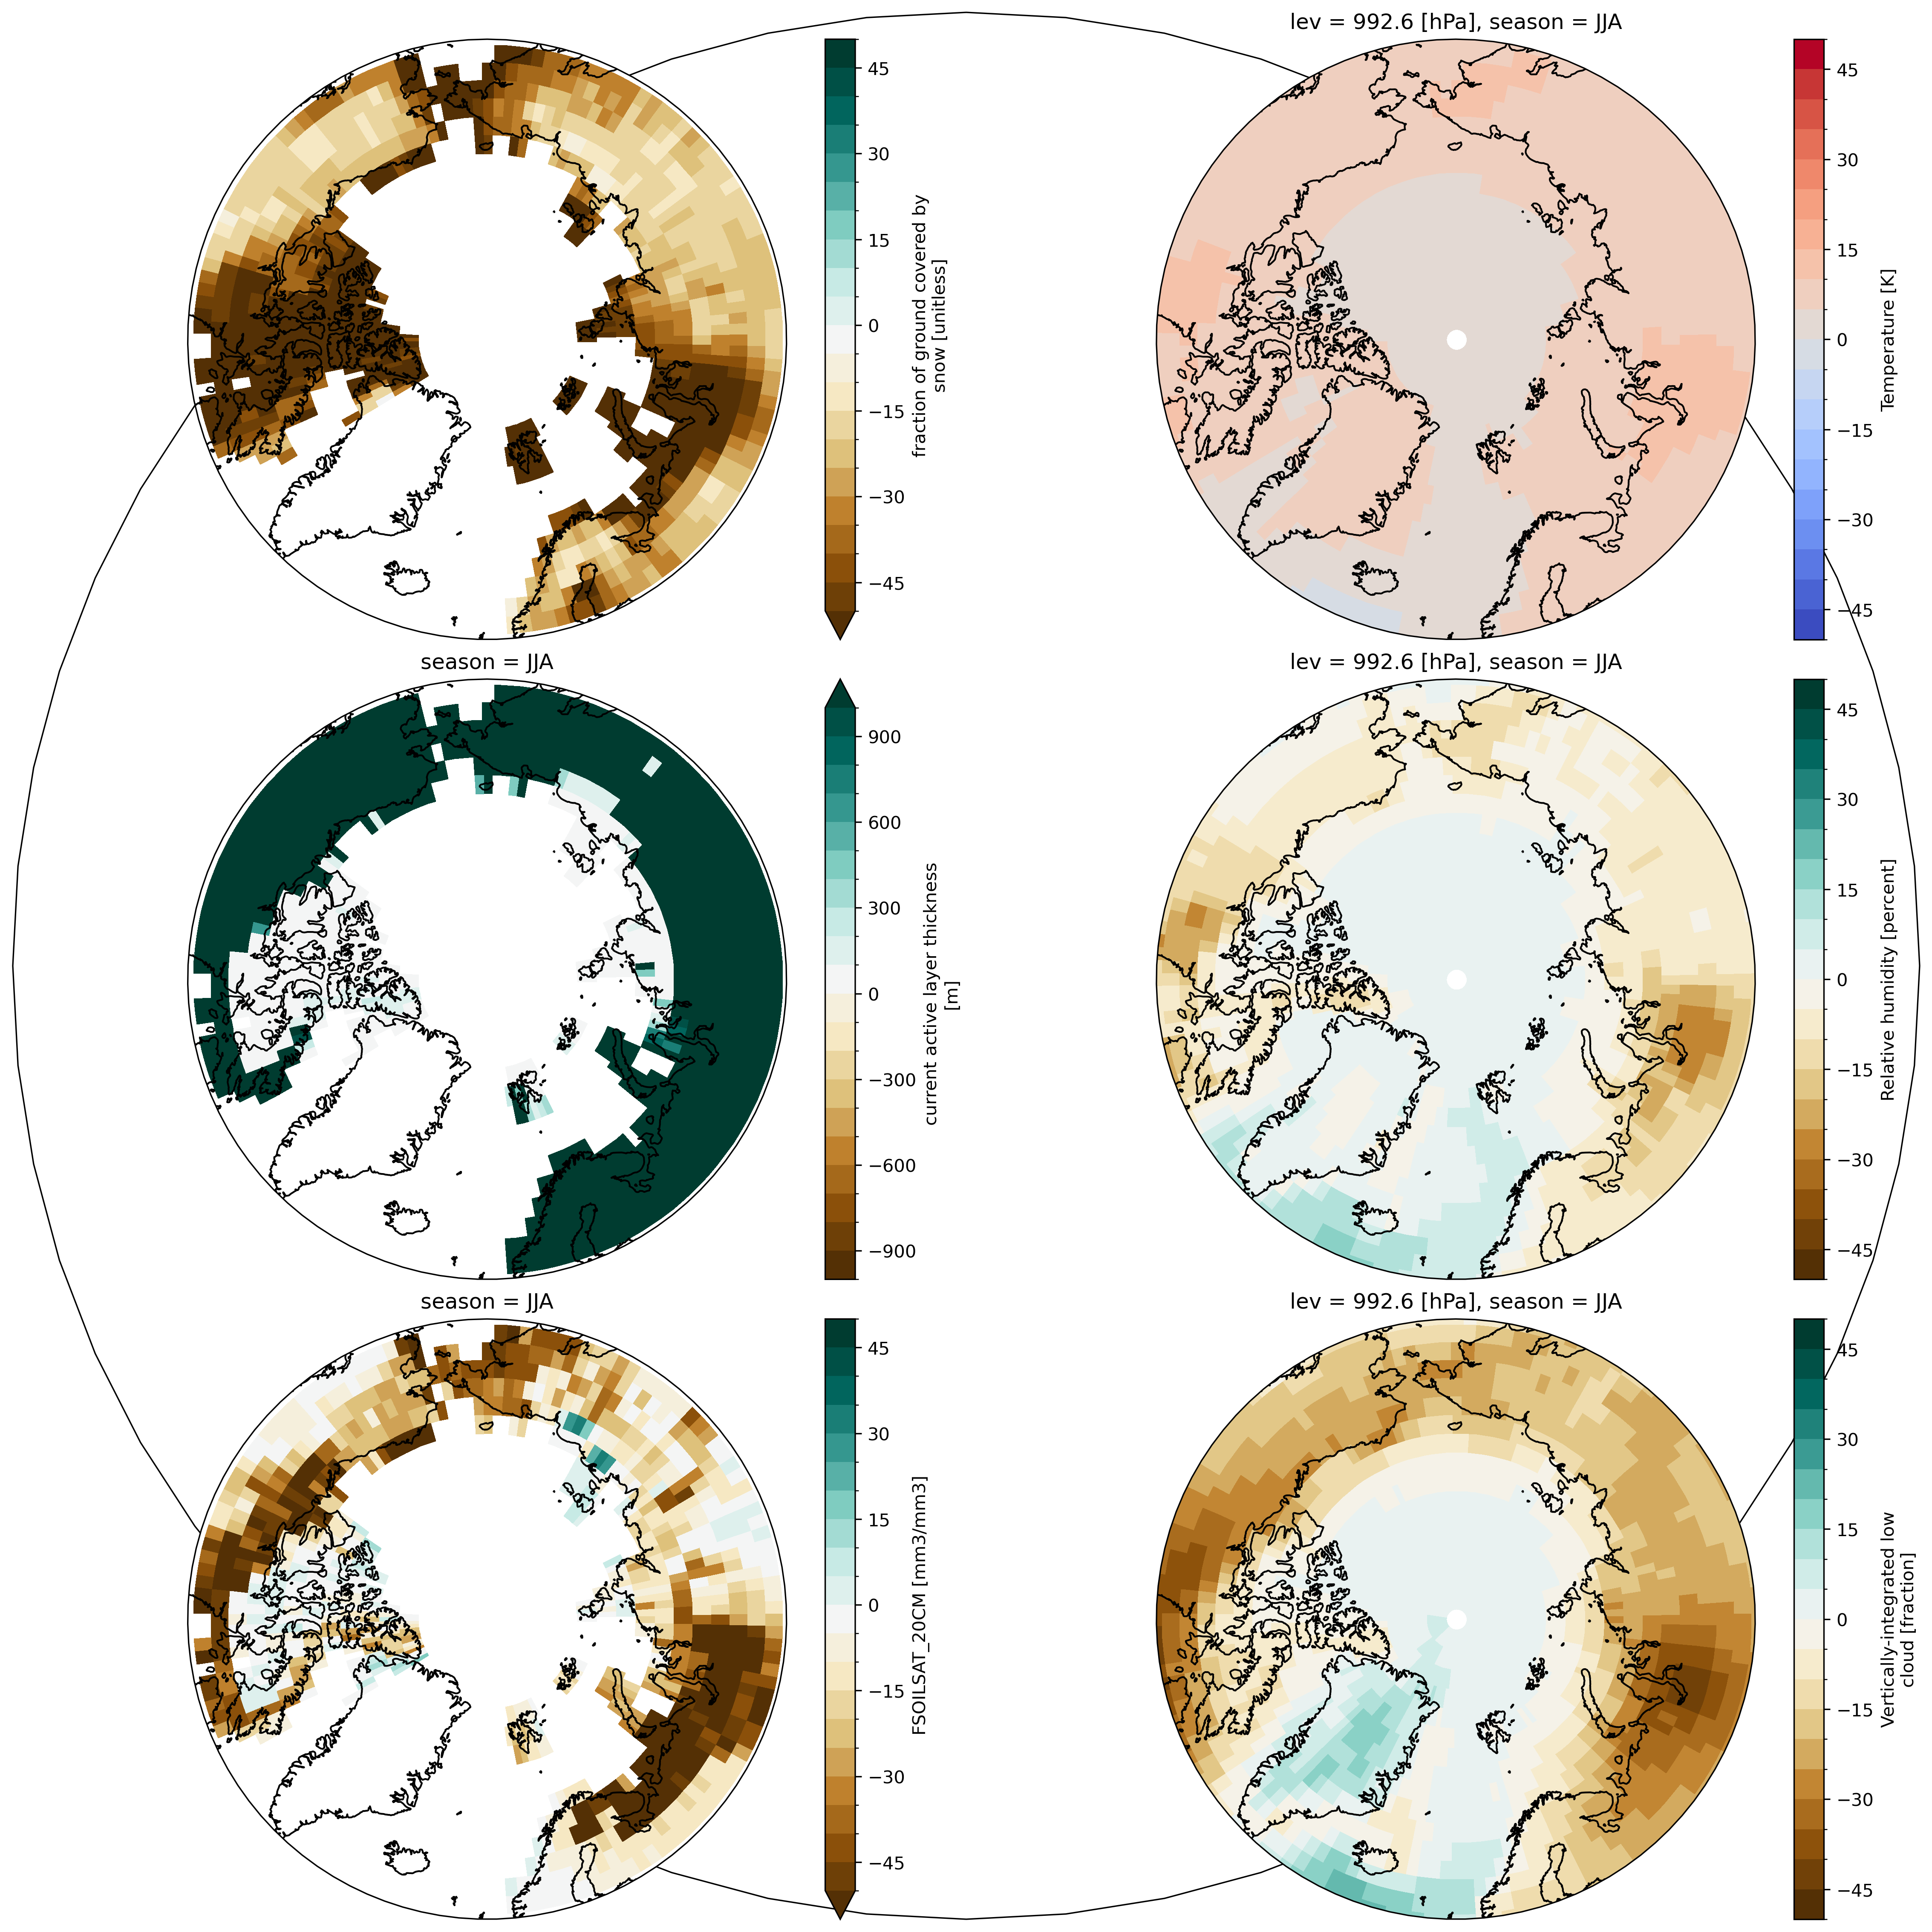

In [65]:
# SPATIAL JJA DIFFERENCE
import cartopy.crs as ccrs

labels = [['(a)','(b)'],['(c)','(d)'],['(e)','(f)']]
vars_lnd = ['FSNO', 'ALT','FSOILSAT_20CM']
vars_atm = ['T', 'RELHUM','CLDLOW']
levels_lnd = [50, 1000, 50]
levels_atm = [50, 50, 50]
colors_lnd = ['BrBG', 'BrBG', 'BrBG']
colors_atm ='coolwarm', 'BrBG', 'BrBG',
units_atm = ['K', '%', '%']
units_lnd =['%', 'm', '%']

fig, axs = plt.subplot_mosaic(mosaic=labels, figsize=(15, 15),dpi=300,sharey=True,constrained_layout=True)
ax = plt.subplot(1,1,1, projection=ccrs.Orthographic(0, 90))
for label in labels[0]+labels[1]+labels[2]:
      ax = axs[label]
      ax.axis('off')

ax1 = fig.add_subplot(3, 2, 1, projection=ccrs.Orthographic(0, 90))
ax2 = fig.add_subplot(3, 2, 2, projection=ccrs.Orthographic(0, 90))
ax3 = fig.add_subplot(3, 2, 3, projection=ccrs.Orthographic(0, 90))
ax4 = fig.add_subplot(3, 2, 4, projection=ccrs.Orthographic(0, 90))
ax5 = fig.add_subplot(3, 2, 5, projection=ccrs.Orthographic(0, 90))
ax6 = fig.add_subplot(3, 2, 6, projection=ccrs.Orthographic(0, 90))

for ax, var, level, unit, colors in zip([ax2, ax4, ax6], vars_atm, levels_atm, units_atm, colors_atm):
    functions.polarCentral_set_latlim([60,90], ax)
    data = ds_4xCO2_m[var].sel(season='JJA') - piClim_m[var].sel(season='JJA')
    if var == 'CLDLOW':
         data = data*100
    ax.set_title(var, fontsize=22,fontweight='bold')
    map = data.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), 
                                        cmap=colors, levels=np.linspace(-level, level, 21))
    ax.coastlines()

for ax, var, level, unit, colors in zip([ax1,ax3, ax5], vars_lnd, levels_lnd, units_lnd, colors_lnd):
    functions.polarCentral_set_latlim([60,90], ax)
    if var == 'FSNO':
       data = ds_4xCO2_i[var].sel(season='JJA') - ds_piClim_i[var].sel(season='JJA') + (ds_4xCO2_i[var].sel(season='MAM') - ds_piClim_i[var].sel(season='MAM'))
    elif var == 'ALT':
        data = ds_4xCO2_i[var].sel(season='JJA').where(ds_4xCO2_i[var].sel(season='JJA')<100)
    else:
        data = ds_4xCO2_i[var].sel(season='JJA') - ds_piClim_i[var].sel(season='JJA')
    if var == 'FSNO' or 'FSOILSAT_20CM':
         data = data*100
    ax.set_title(var, fontsize=22,fontweight='bold')
    map = data.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), 
                                        cmap=colors, levels=np.linspace(-level, level, 21))
    ax.coastlines()


#    cb = plt.colorbar(map, ax=ax,drawedges=True,
#                        location='bottom',orientation='horizontal')

#    cb.set_label(unit,fontsize=18)
#    cb.ax.tick_params(labelsize=18)